# EDA — Car Damage Detection Dataset

In [3]:
import json, os, random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

DATA_ROOT = r'..\data\raw\CarDD_release\CarDD_COCO'
ANN_DIR   = os.path.join(DATA_ROOT, 'annotations')

COLORS = {
    'dent': '#e74c3c', 'scratch': '#3498db', 'crack': '#2ecc71',
    'glass shatter': '#f39c12', 'lamp broken': '#9b59b6', 'tire flat': '#1abc9c'
}

def load_coco(split):
    with open(os.path.join(ANN_DIR, f'instances_{split}.json')) as f:
        return json.load(f)

train = load_coco('train2017')
val   = load_coco('val2017')
test  = load_coco('test2017')

cat_map = {c['id']: c['name'] for c in train['categories']}
cats    = list(cat_map.values())
cat_map

{1: 'dent',
 2: 'scratch',
 3: 'crack',
 4: 'glass shatter',
 5: 'lamp broken',
 6: 'tire flat'}

## 1. Split Overview

In [4]:
print(f"{'Split':<12} {'Images':>8} {'Annotations':>14} {'Avg per image':>14}")
print('-' * 50)
for name, data in [('train2017', train), ('val2017', val), ('test2017', test)]:
    n_img = len(data['images'])
    n_ann = len(data['annotations'])
    print(f"{name:<12} {n_img:>8} {n_ann:>14} {n_ann/n_img:>14.2f}")

Split          Images    Annotations  Avg per image
--------------------------------------------------
train2017        2816           6211           2.21
val2017           810           1744           2.15
test2017          374            785           2.10


## 2. Sample Images with Damage Boxes

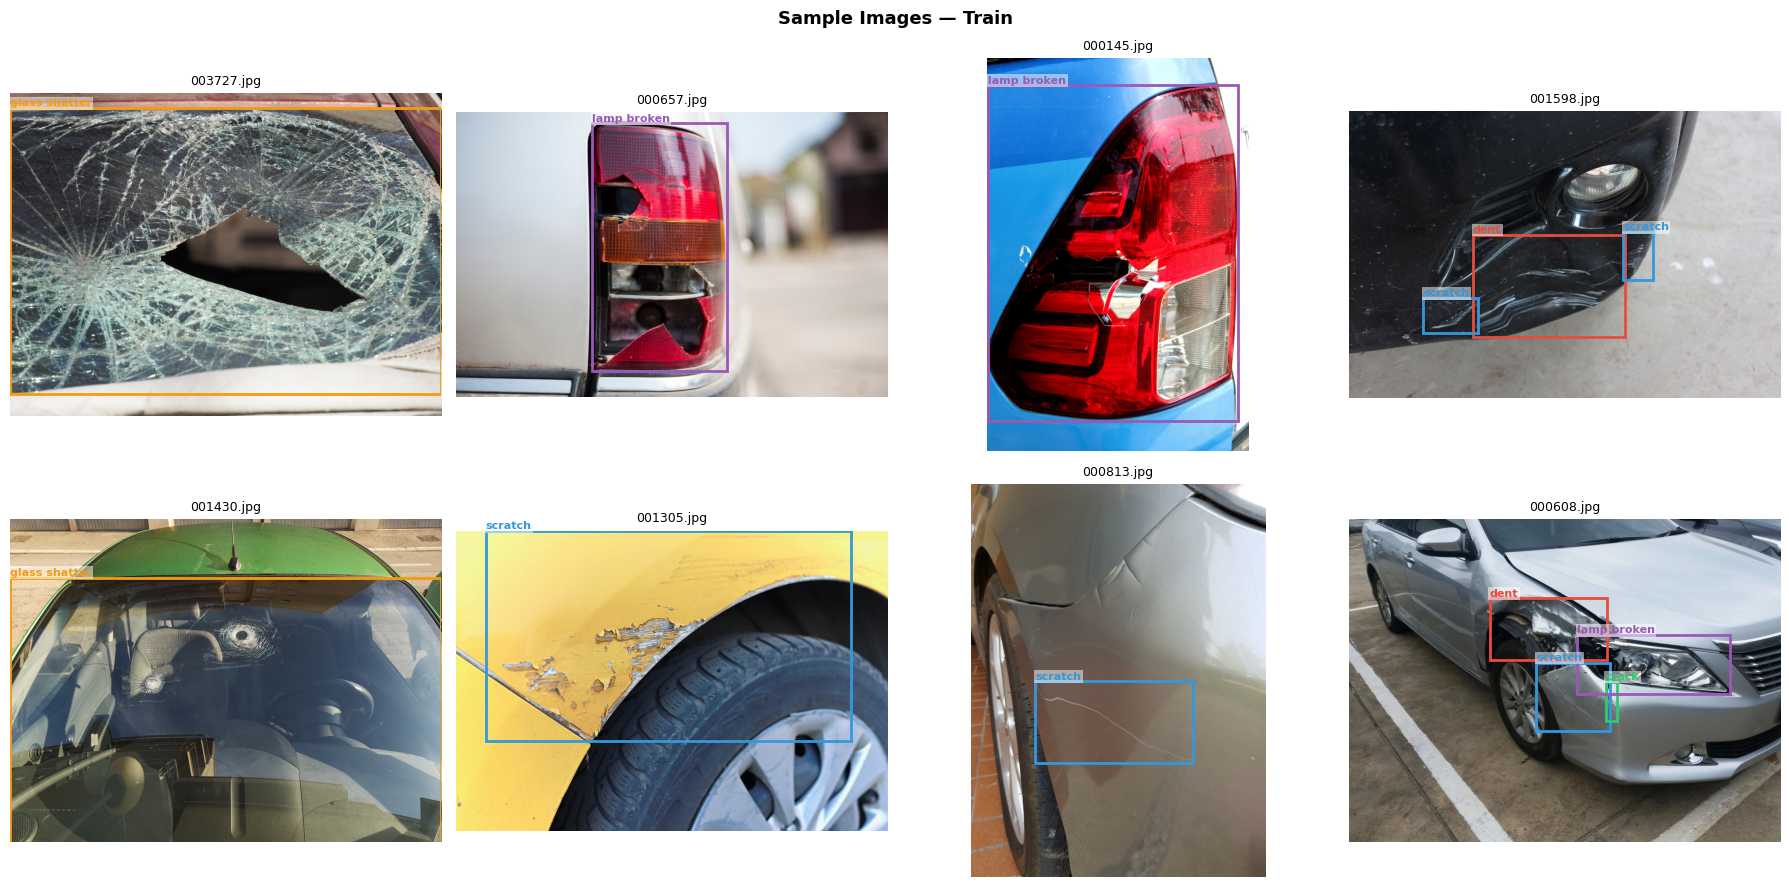

In [9]:
random.seed(42)
ann_by_img = defaultdict(list)
for ann in train['annotations']:
    ann_by_img[ann['image_id']].append(ann)

ann_by_img

img_lookup = {img['id']: img for img in train['images']}
sample_ids = random.sample(list(ann_by_img.keys()), 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    img_info = img_lookup[img_id]
    img = mpimg.imread(os.path.join(DATA_ROOT, 'train2017', img_info['file_name']))
    ax.imshow(img)
    for ann in ann_by_img[img_id]:
        x, y, w, h = ann['bbox']
        cat = cat_map[ann['category_id']]
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                   edgecolor=COLORS[cat], facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 4, cat, color=COLORS[cat], fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))
    ax.set_title(img_info['file_name'], fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Images — Train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Damage Category Distribution

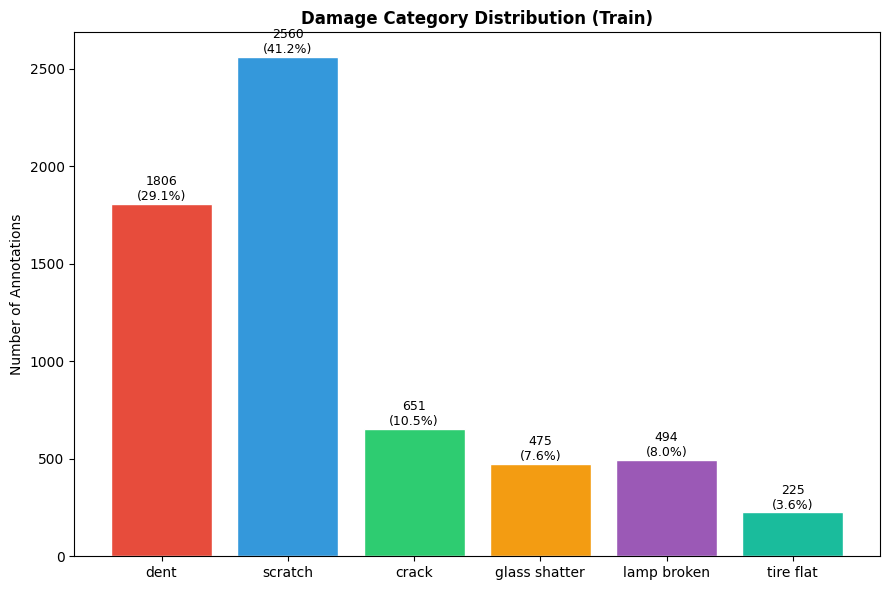

In [12]:
counts = Counter(cat_map[a['category_id']] for a in train['annotations'])

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(cats, [counts[c] for c in cats],
              color=[COLORS[c] for c in cats], edgecolor='white')

for bar in bars:
    h = bar.get_height()
    pct = h / sum(counts.values()) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, h + 20,
            f'{h}\n({pct:.1f}%)', ha='center', fontsize=9)

ax.set_ylabel('Number of Annotations')
ax.set_title('Damage Category Distribution (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. BBox Area by Damage Type (Severity Proxy)

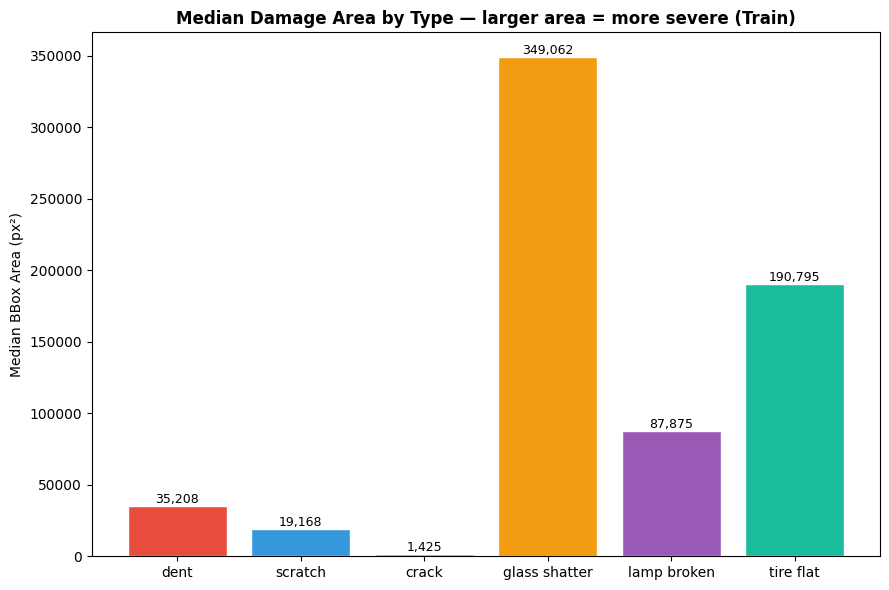

Category         Count  Median px2   Mean px2
----------------------------------------------
glass shatter      475      349062     356861
tire flat          225      190795     201844
lamp broken        494       87875     117704
dent              1806       35208      59060
scratch           2560       19168      41341
crack              651        1425       4104


In [14]:
areas = defaultdict(list)
for ann in train['annotations']:
    areas[cat_map[ann['category_id']]].append(ann['area'])

medians = [np.median(areas[c]) for c in cats]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(cats, medians, color=[COLORS[c] for c in cats], edgecolor='white')

for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2000,
            f'{val:,.0f}', ha='center', fontsize=9)

ax.set_ylabel('Median BBox Area (px²)')
ax.set_title('Median Damage Area by Type — larger area = more severe (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'Category':<15} {'Count':>6} {'Median px2':>11} {'Mean px2':>10}")
print('-' * 46)
for cat in sorted(cats, key=lambda c: np.median(areas[c]), reverse=True):
    print(f"{cat:<15} {len(areas[cat]):>6} {np.median(areas[cat]):>11.0f} {np.mean(areas[cat]):>10.0f}")